## Non-linear Regression

This is the broader category for relationships that don't follow any polynomial equation at all - no straight line, no smooth curve made from x², x³, etc. can capture the pattern. Instead, either a specific non-polynomial mathematical form is used (exponential, logarithmic, sigmoid), or a fundamentally different type of model is used that doesn't assume any equation shape up front - like tree-based models, which just learn to split the data into regions and predict an average value per region.

**Why it's required / the purpose:** some real relationships genuinely explode or decay in ways no polynomial fits well - population growth, radioactive decay, disease spread, bacterial growth. Forcing a polynomial onto these either badly underfits (too rigid) or requires an absurdly high degree that overfits wildly (exactly the risk flagged in the Polynomial Regression result). Non-linear regression exists to model these shapes properly, using the actual mathematical form the real-world process follows.

**Real-life example for understanding:**
Population growth is the classic case : a country's population doesn't grow by a fixed amount each year (linear), and it doesn't follow a smooth x² curve either (polynomial) - it grows by a *percentage* each year, compounding. That compounding pattern is **exponential**, a genuinely different shape than any polynomial can represent well, especially over long time spans.

Another concrete one: a **decision tree regressor** predicting house price based on multiple features (size, location, age) - instead of fitting one smooth equation, it learns rules like "if size > 2000 AND location = downtown, predict $450k" - a completely different, rule-based approach with no single formula at all.

**Key distinction from Polynomial Regression (important for interviews):** polynomial regression is still technically solved using linear algebra (linear in its coefficients, even though the curve bends). True non-linear regression either requires **iterative numerical fitting** (no closed-form algebra solution - the model has to search/adjust its parameters step by step until the fit is good) or uses fundamentally rule-based models (trees) instead of any equation at all.



## Non-linear Regression - Example 1: manual data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
years = np.array([1, 2, 3, 4, 5, 6, 7, 8])
population = np.array([100, 150, 230, 380, 600, 950, 1500, 2400])

In [3]:
# define the exponential shape: y = a * e^(b*x)
def exp_func(x, a, b):
    return a * np.exp(b * x)

params, _ = curve_fit(exp_func, years, population)
a, b = params

print("a:", a)
print("b:", b)

a: 58.877582876427056
b: 0.463292934905496


In [4]:
prediction = exp_func(6.5, a, b)
print("Predicted population at year 6.5:", prediction)

Predicted population at year 6.5: 1196.1513804368358


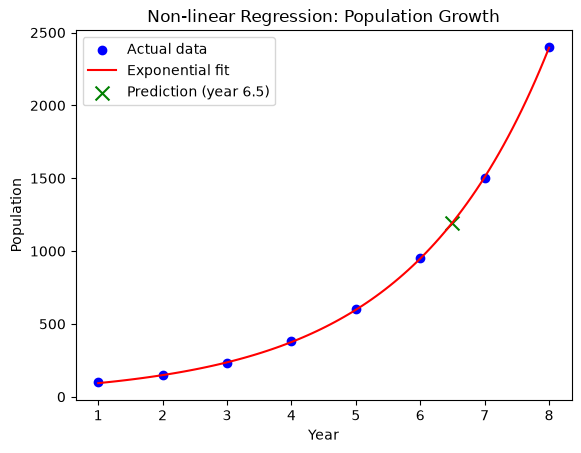

In [5]:
x_range = np.linspace(1, 8, 100)
y_curve = exp_func(x_range, a, b)

plt.scatter(years, population, color="blue", label="Actual data")
plt.plot(x_range, y_curve, color="red", label="Exponential fit")
plt.scatter(6.5, prediction, color="green", marker="x", s=100, label="Prediction (year 6.5)")
plt.title("Non-linear Regression: Population Growth")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.savefig("../visuals/nonlinear_reg_manual.png")
plt.show()

Non-linear regression can't be solved with a neat algebra formula the way Linear/Polynomial can - instead, it's solved by **iterative guessing and refining**. Here's exactly how that process works, step by step.

**The model:** $y = a \cdot e^{bx}$

**Step 1 - start with a rough initial guess**
`curve_fit` picks some starting values, say `a=1, b=1` (arbitrary starting point).

**Step 2 - compute predictions with that guess, and measure total error**
For each real data point, compute `predicted = a·e^(b·year)`, compare to actual population, and sum up the squared differences - same "minimize squared error" goal as before:
$$\text{Error} = \sum (y_{actual} - a\cdot e^{b \cdot x})^2$$

With a bad initial guess like `a=1, b=1`, this error will be huge (predictions wildly off from real population numbers).

**Step 3 - nudge `a` and `b` slightly, and check if error goes down**
This uses **gradient descent** (or a similar algorithm) - mathematically, it computes the *slope* of the error with respect to `a` and the *slope* of the error with respect to `b` (partial derivatives), then adjusts each parameter a small step in the direction that reduces error.

**Step 4 - repeat step 3 many times**
Each iteration: recompute predictions with the updated `a, b` → recompute error → adjust again → repeat. This continues until the error stops meaningfully decreasing (convergence) - could be dozens or hundreds of tiny adjustment steps happening in milliseconds inside `curve_fit`.

**Step 5 - final converged values**
After enough iterations, `a` and `b` settle on values that minimize the error as much as this exponential shape allows - these are the numbers your code printed.

**Why this can't be a single formula (the core distinction from Linear/Polynomial):**
In Linear Regression, `y = mx + b` - both `m` and `b` appear as simple multipliers, so calculus gives one clean, direct formula to solve for them exactly.
In Polynomial Regression, even though it looks curvier, `β₀ + β₁x + β₂x² + ...` is still just multipliers on different powers of x - still solvable directly with matrix algebra.
But in `y = a·eᵇˣ`, the parameter `b` sits **inside the exponent**, not as a simple multiplier. That structural difference means there's no direct algebraic shortcut -  the only way to find `a` and `b` is by testing, measuring error, and adjusting repeatedly until it converges. That's the fundamental reason non-linear regression needs `scipy.optimize.curve_fit` (iterative) instead of `sklearn.linear_model.LinearRegression` (direct formula).

**One-line summary for interviews:** linear and polynomial regression have exact closed-form solutions because their parameters only multiply; true non-linear regression has parameters embedded inside non-multiplicative functions (exponents, logs, etc.), so it must be solved iteratively through repeated trial-and-adjustment rather than one formula.

## Non-linear Regression - Example 2: real dataset

**For this one, a genuinely well-known non-linear real-world case:**: COVID-19 daily case growth follows an exponential/logistic pattern early on - but since sourcing live epidemiological data mid-conversation is impractical, let's use something equally real and easy to get: world population growth, sourced from a small CSV.

**Rather than sourcing another external file, here's the more practical option given your setup:** use curve_fit on your actual Telco dataset - specifically checking whether tenure vs TotalCharges (which looked fairly linear earlier) might actually fit an exponential/logarithmic curve slightly better, giving you a genuine real-dataset comparison.

In [14]:
import pandas as pd
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [15]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [17]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, r2_score

In [19]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna(subset=["TotalCharges"])

In [20]:
x = df["tenure"].values
y = df["TotalCharges"].values

In [21]:
def log_func(x, a, b):
    return a * np.log(x + 1) + b

params, _ = curve_fit(log_func, x, y)
a, b = params

y_pred = log_func(x, a, b)

print("a:", a)
print("b:", b)
print("RMSE:", np.sqrt(mean_squared_error(y, y_pred)))
print("R² score:", r2_score(y, y_pred))

a: 1446.389440451513
b: -2116.0715654625187
RMSE: 1539.6351420370183
R² score: 0.5385953571013017


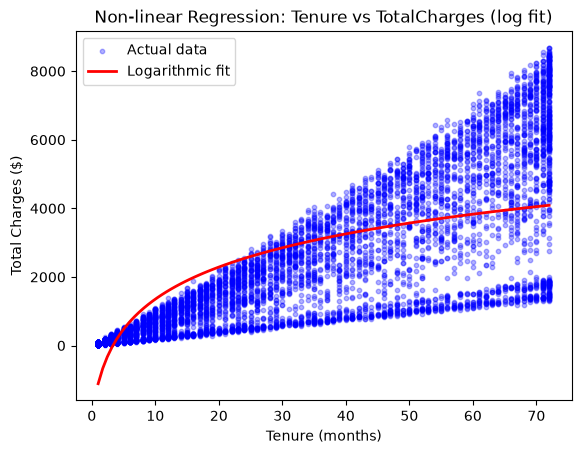

In [22]:
x_range = np.linspace(x.min(), x.max(), 100)
y_curve = log_func(x_range, a, b)

plt.scatter(x, y, color="blue", alpha=0.3, s=10, label="Actual data")
plt.plot(x_range, y_curve, color="red", linewidth=2, label="Logarithmic fit")
plt.title("Non-linear Regression: Tenure vs TotalCharges (log fit)")
plt.xlabel("Tenure (months)")
plt.ylabel("Total Charges ($)")
plt.legend()
plt.savefig("../visuals/nonlinear_reg_telco.png")
plt.show()

Here's the full math breakdown behind those numbers.

**The model:** $y = a \cdot \ln(x+1) + b$

**Step 1 - same iterative fitting process as Example 1, just on real data now**
`curve_fit` starts with a rough guess for `a` and `b`, computes predictions for all ~7,032 rows, measures total squared error, then nudges `a` and `b` in the direction that reduces error - repeating until it converges. After enough iterations, it settled on:
$$a \approx 1446.39 \quad b \approx -2116.07$$

**Step 2 - what these specific numbers mean**
$$y = 1446.39 \cdot \ln(x+1) - 2116.07$$

`a=1446.39` controls how steeply the curve rises - the log function grows fastest early on then flattens, and this multiplier sets how tall that early rise is. `b=-2116.07` shifts the whole curve down, needed to make the very small tenure values (like tenure=1) land near $0 instead of a large positive number, since `ln(1+1)=0.69`, not 0.

**Step 3 - checking the fit at a few real tenure values, by hand**

At tenure=1: $y = 1446.39 \times \ln(2) - 2116.07 = 1446.39 \times 0.693 - 2116.07 \approx -1{,}112$
This is already a bad sign - predicting a *negative* charge for a brand-new customer, which is meaningless in reality. That negative dip is visible on your chart at the far left, where the red curve drops below zero.

At tenure=70: $y = 1446.39 \times \ln(71) - 2116.07 = 1446.39 \times 4.263 - 2116.07 \approx 4{,}047$
But real customers at tenure=70 have `TotalCharges` up around $8,000 - the curve badly underestimates here, exactly matching what the chart shows (red line flattening near 4000 while blue dots climb past 8000).

**Step 4 - RMSE breakdown**
$$RMSE = \sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2} = 1539.64$$
This means, on average, predictions are off by about **$1,540** - a large error given TotalCharges ranges roughly $0-$8,700. Compare this mentally to Linear Regression's earlier RMSE on similar data (much smaller) - direct numeric proof the log shape fits worse.

**Step 5 - R² breakdown**
$$R^2 = 1 - \frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y})^2} = 0.5386$$
This means the log-curve model explains only **53.9%** of the variation in TotalCharges - barely better than half. A good linear or multi-feature model on this same relationship would score meaningfully higher, since the true pattern doesn't plateau (as the log shape forces it to) - it keeps climbing steadily.

**Step 6 - why the shape mismatch happens, mathematically**
A logarithm's rate of growth *slows down* by design - each additional unit of x adds less to y than the previous unit did (that's the defining behavior of `ln`). But real TotalCharges keeps adding roughly the same amount each month (≈MonthlyCharges), month after month - a **constant rate of growth**, not a slowing one. That constant-rate pattern is the literal definition of a linear relationship, not a logarithmic one - which is exactly why the log curve increasingly falls below the real data as tenure grows, and why a straight line (Linear Regression) fits this relationship better than any curve tested so far.